In [3]:
"""
GTSRB 交通标志识别 - GoogLeNet 版本
Jupyter Notebook 分步运行版
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import pandas as pd
import os
import time
import matplotlib.pyplot as plt

print(f"PyTorch 版本: {torch.__version__}")
print(f"设备可用: MPS={torch.backends.mps.is_available()}, CUDA={torch.cuda.is_available()}")

PyTorch 版本: 2.13.0
设备可用: MPS=True, CUDA=False


In [4]:
# ══════════════════════════════════════════════════════════════
#  第 1 块：全局配置（改参数只改这里）
# ══════════════════════════════════════════════════════════════
import os
print("当前工作目录:", os.getcwd())
print("当前目录内容:", os.listdir('.'))
class CFG:
    """所有超参数集中在这里"""
    # ---- 数据路径（根据你的实际解压位置修改） ----
    DATA_ROOT = "."                  
    TRAIN_DIR = os.path.join(DATA_ROOT, "Train")   # 去掉 archive，直接 Train/
    TEST_DIR = os.path.join(DATA_ROOT, "Test")     # 去掉 archive，直接 Test/
    TRAIN_CSV = os.path.join(DATA_ROOT, "Train.csv")
    TEST_CSV = os.path.join(DATA_ROOT, "Test.csv")
    
    # ---- 图像 ----
    IMG_SIZE = 64
    USE_ROI_CROP = False    # True=用CSV坐标裁剪标志区域，False=整张图
    
    # ---- 训练 ----
    BATCH_SIZE = 64
    NUM_WORKERS = 0         # MPS必须0
    EPOCHS = 30
    LR = 1e-3
    WEIGHT_DECAY = 1e-4
    EARLY_STOP_PATIENCE = 5
    LR_SCHEDULER_PATIENCE = 3
    LR_SCHEDULER_FACTOR = 0.5
    
    # ---- 模型 ----
    NUM_CLASSES = 43
    DROPOUT = 0.4
    
    # ---- 设备 & 保存 ----
    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    SAVE_PATH = "./gtsrb_googlenet_best.pth"

print(f"设备: {CFG.DEVICE}")
print(f"图像尺寸: {CFG.IMG_SIZE}")
print(f"使用ROI裁剪: {CFG.USE_ROI_CROP}")
print(f"Batch: {CFG.BATCH_SIZE}, LR: {CFG.LR}, WeightDecay: {CFG.WEIGHT_DECAY}")

# 检查数据路径是否存在
if os.path.exists(CFG.TRAIN_DIR):
    print(f"\n✅ 训练集路径存在: {CFG.TRAIN_DIR}")
    print(f"   子文件夹(类别): {sorted([d for d in os.listdir(CFG.TRAIN_DIR) if d.isdigit()], key=int)}")
else:
    print(f"\n❌ 找不到训练集: {CFG.TRAIN_DIR}")
    print("请修改 CFG.DATA_ROOT 为你的实际解压路径")

if os.path.exists(CFG.TEST_CSV):
    print(f"✅ 测试标注存在: {CFG.TEST_CSV}")
else:
    print(f"⚠️  测试标注未找到: {CFG.TEST_CSV}")

当前工作目录: /Users/omegahodge/Desktop/交通信号灯的测试/archive
当前目录内容: ['gtsrb_googlenet_full.pth', '.DS_Store', 'Test', 'Test.csv', 'gtsrb_googlenet_best.pth', 'Meta', 'gtsrb_googlenet.ipynb', 'Train', 'Meta.csv', 'Train.csv']
设备: mps
图像尺寸: 64
使用ROI裁剪: False
Batch: 64, LR: 0.001, WeightDecay: 0.0001

✅ 训练集路径存在: ./Train
   子文件夹(类别): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42']
✅ 测试标注存在: ./Test.csv


In [17]:
# ══════════════════════════════════════════════════════════════
#  第 2 块：自定义 Dataset（适配 GTSRB 的 CSV 标注格式）
# ══════════════════════════════════════════════════════════════

class GTSRBDataset(Dataset):
    """
    GTSRB 数据集
    训练集: 文件夹模式（子文件夹名=类别ID）
    测试集: CSV模式（图片在一个文件夹，标签在CSV）
    可选: 用ROI坐标裁剪标志区域
    """
    def __init__(self, root_dir, csv_file=None, transform=None, use_roi=False):
        self.root_dir = root_dir
        self.transform = transform
        self.use_roi = use_roi
        self.samples = []  # [(img_path, class_id, roi), ...]
        
        if csv_file is not None and os.path.exists(csv_file):
            # ---- CSV模式（测试集） ----
            df = pd.read_csv(csv_file)
            for _, row in df.iterrows():
                img_path = os.path.join(self.root_dir, os.path.basename(row['Path']))
                class_id = int(row['ClassId'])
                roi = (int(row['Roi.X1']), int(row['Roi.Y1']),
                       int(row['Roi.X2']), int(row['Roi.Y2'])) if use_roi else None
                self.samples.append((img_path, class_id, roi))
        else:
            # ---- 文件夹模式（训练集） ----
            for class_id_str in sorted(os.listdir(root_dir), key=lambda x: int(x) if x.isdigit() else -1):
                class_dir = os.path.join(root_dir, class_id_str)
                if not os.path.isdir(class_dir) or not class_id_str.isdigit():
                    continue
                class_id = int(class_id_str)
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.ppm')):
                        img_path = os.path.join(class_dir, img_name)
                        self.samples.append((img_path, class_id, None))
        
        print(f"  加载 {len(self.samples)} 张图片 from {root_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label, roi = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        
        if self.use_roi and roi is not None:
            x1, y1, x2, y2 = roi
            img = img.crop((x1, y1, x2, y2))
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

print("✅ Dataset 类定义完成")

✅ Dataset 类定义完成


In [18]:
# ══════════════════════════════════════════════════════════════
#  第 3 块：数据增强 + DataLoader
# ══════════════════════════════════════════════════════════════

def get_transforms(img_size):
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    return train_transform, test_transform


def get_dataloaders(cfg):
    train_transform, test_transform = get_transforms(cfg.IMG_SIZE)
    
    # ---- 训练集 ----
    print("[加载训练集]")
    full_train_dataset = GTSRBDataset(
        root_dir=cfg.TRAIN_DIR,
        csv_file=None,
        transform=train_transform,
        use_roi=cfg.USE_ROI_CROP
    )
    
    # 80/20 划分
    train_size = int(0.8 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    train_set, val_set = random_split(
        full_train_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    val_set.dataset.transform = test_transform
    
    train_loader = DataLoader(train_set, batch_size=cfg.BATCH_SIZE,
                               shuffle=True, num_workers=cfg.NUM_WORKERS)
    val_loader = DataLoader(val_set, batch_size=cfg.BATCH_SIZE,
                             shuffle=False, num_workers=cfg.NUM_WORKERS)
    
    # ---- 测试集 ----
    test_loader = None
    if os.path.exists(cfg.TEST_CSV) and os.path.exists(cfg.TEST_DIR):
        print("[加载测试集]")
        test_dataset = GTSRBDataset(
            root_dir=cfg.TEST_DIR,
            csv_file=cfg.TEST_CSV,
            transform=test_transform,
            use_roi=cfg.USE_ROI_CROP
        )
        test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE,
                                  shuffle=False, num_workers=cfg.NUM_WORKERS)
    
    print(f"\n训练: {len(train_set)} | 验证: {val_size} | "
          f"测试: {len(test_loader.dataset) if test_loader else 'N/A'}")
    
    return train_loader, val_loader, test_loader


# 执行加载
train_loader, val_loader, test_loader = get_dataloaders(CFG)

# 取一个 batch 看看
X, y = next(iter(train_loader))
print(f"\nBatch 形状: X={X.shape}, y={y.shape}")
print(f"标签示例: {y[:10].tolist()}")

[加载训练集]
  加载 39209 张图片 from ./Train
[加载测试集]
  加载 12630 张图片 from ./Test

训练: 31367 | 验证: 7842 | 测试: 12630

Batch 形状: X=torch.Size([64, 3, 64, 64]), y=torch.Size([64])
标签示例: [2, 10, 11, 19, 9, 33, 9, 2, 4, 9]


/var/folders/pz/wgh5bkwx749c_gn61_9m9vcm0000gn/T/ipykernel_54836/2479160909.py:27: UserWarning: Glyph 38480 (\N{CJK UNIFIED IDEOGRAPH-9650}) missing from current font.
  plt.tight_layout()
/var/folders/pz/wgh5bkwx749c_gn61_9m9vcm0000gn/T/ipykernel_54836/2479160909.py:27: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from current font.
  plt.tight_layout()
/var/folders/pz/wgh5bkwx749c_gn61_9m9vcm0000gn/T/ipykernel_54836/2479160909.py:27: UserWarning: Glyph 31105 (\N{CJK UNIFIED IDEOGRAPH-7981}) missing from current font.
  plt.tight_layout()
/var/folders/pz/wgh5bkwx749c_gn61_9m9vcm0000gn/T/ipykernel_54836/2479160909.py:27: UserWarning: Glyph 21345 (\N{CJK UNIFIED IDEOGRAPH-5361}) missing from current font.
  plt.tight_layout()
/var/folders/pz/wgh5bkwx749c_gn61_9m9vcm0000gn/T/ipykernel_54836/2479160909.py:27: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from current font.
  plt.tight_layout()
/var/folders/pz/wgh5bkwx749c_gn61_9m9vcm0000gn/T/ipyker

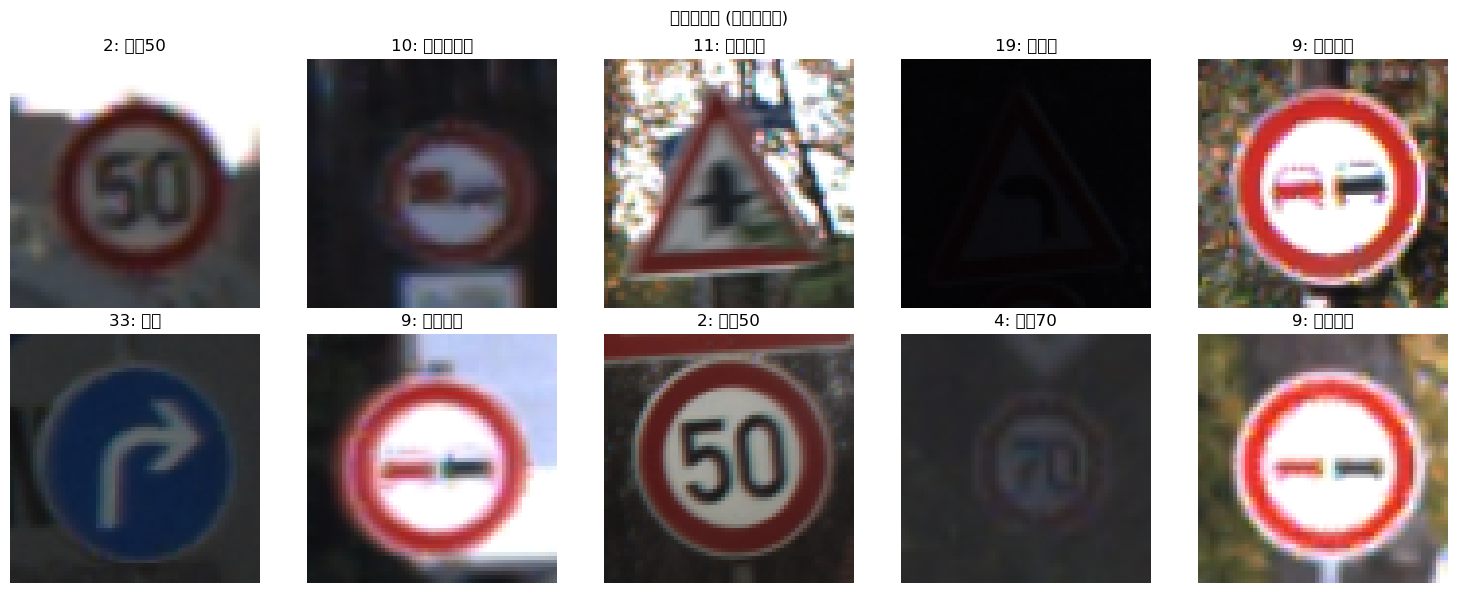

In [19]:
# ══════════════════════════════════════════════════════════════
#  可选：可视化一个 batch 的图片
# ══════════════════════════════════════════════════════════════

SIGN_NAMES = {
    0: "限速20", 1: "限速30", 2: "限速50", 3: "限速60", 4: "限速70",
    5: "限速80", 6: "限速80结束", 7: "限速100", 8: "限速120", 9: "禁止超车",
    10: "禁卡车超车", 11: "交叉路口", 12: "优先道路", 13: "让行",
    14: "停车", 15: "禁止通行", 16: "禁卡车", 17: "禁止进入",
    18: "注意", 19: "左急弯", 20: "右急弯", 21: "连续弯道",
    22: "颠簸", 23: "路滑", 24: "变窄", 25: "施工",
    26: "信号灯", 27: "行人", 28: "儿童", 29: "自行车",
    30: "冰雪", 31: "野生动物", 32: "限速结束", 33: "右转",
    34: "左转", 35: "直行", 36: "直或右转", 37: "直或左转",
    38: "靠右", 39: "靠左", 40: "环岛", 41: "限速结束2",
    42: "禁超车结束"
}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    img = X[i].permute(1, 2, 0).numpy() * 0.5 + 0.5  # 反归一化
    axes[i].imshow(img.clip(0, 1))
    axes[i].set_title(f"{y[i].item()}: {SIGN_NAMES.get(y[i].item(), '?')}")
    axes[i].axis('off')
plt.suptitle("训练集样本 (数据增强后)")
plt.tight_layout()
plt.show()

In [20]:
# ══════════════════════════════════════════════════════════════
#  第 4 块：GoogLeNet 模型定义
# ══════════════════════════════════════════════════════════════

class Inception(nn.Module):
    """Inception块：4路并行"""
    def __init__(self, in_ch, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_ch, ch1x1, kernel_size=1),
            nn.BatchNorm2d(ch1x1), nn.ReLU(inplace=True)
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_ch, ch3x3red, kernel_size=1),
            nn.BatchNorm2d(ch3x3red), nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3red, ch3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(ch3x3), nn.ReLU(inplace=True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_ch, ch5x5red, kernel_size=1),
            nn.BatchNorm2d(ch5x5red), nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5red, ch5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(ch5x5), nn.ReLU(inplace=True)
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_ch, pool_proj, kernel_size=1),
            nn.BatchNorm2d(pool_proj), nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x),
                          self.branch3(x), self.branch4(x)], dim=1)


class GoogLeNet(nn.Module):
    """适配64x64输入的简化GoogLeNet"""
    def __init__(self, num_classes=43, dropout=0.4):
        super().__init__()
        
        # 初始卷积: 64x64 -> 32x32
        self.pre_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Inception 1: 64ch -> 128ch (32+48+12+36)
        self.inception1 = Inception(64, ch1x1=32, ch3x3red=32, ch3x3=48,
                                     ch5x5red=8, ch5x5=12, pool_proj=36)
        self.pool1 = nn.MaxPool2d(2, 2)   # 32->16
        
        # Inception 2: 128ch -> 256ch (64+96+32+64)
        self.inception2 = Inception(128, ch1x1=64, ch3x3red=64, ch3x3=96,
                                     ch5x5red=16, ch5x5=32, pool_proj=64)
        self.pool2 = nn.MaxPool2d(2, 2)   # 16->8
        
        # Inception 3: 256ch -> 512ch (128+192+64+128)
        self.inception3 = Inception(256, ch1x1=128, ch3x3red=96, ch3x3=192,
                                     ch5x5red=32, ch5x5=64, pool_proj=128)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.pre_layers(x)       # (B,64,32,32)
        x = self.inception1(x)       # (B,128,32,32)
        x = self.pool1(x)            # (B,128,16,16)
        x = self.inception2(x)       # (B,256,16,16)
        x = self.pool2(x)            # (B,256,8,8)
        x = self.inception3(x)       # (B,512,8,8)
        x = self.avgpool(x)          # (B,512,1,1)
        x = torch.flatten(x, 1)      # (B,512)
        x = self.dropout(x)
        return self.fc(x)            # (B,43)


# 创建模型并查看参数量
model = GoogLeNet(num_classes=CFG.NUM_CLASSES, dropout=CFG.DROPOUT).to(CFG.DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"GoogLeNet 参数量: {params:,} ({params/1e6:.2f}M)")

# 测试前向传播
with torch.no_grad():
    test_out = model(X[:2].to(CFG.DEVICE))
    print(f"前向测试: 输入{X[:2].shape} -> 输出{test_out.shape}")

GoogLeNet 参数量: 497,587 (0.50M)
前向测试: 输入torch.Size([2, 3, 64, 64]) -> 输出torch.Size([2, 43])


In [21]:
# ══════════════════════════════════════════════════════════════
#  第 5 块：训练 & 验证函数
# ══════════════════════════════════════════════════════════════

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        out = model(X)
        loss = criterion(out, y)
        total_loss += loss.item() * X.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)
    return total_loss / total, 100.0 * correct / total

print("✅ 训练/验证函数定义完成")

✅ 训练/验证函数定义完成


In [22]:
# ══════════════════════════════════════════════════════════════
#  第 6 块：早停器
# ══════════════════════════════════════════════════════════════

class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_state = None
    
    def __call__(self, val_acc, model):
        if self.best_score is None:
            self.best_score = val_acc
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif val_acc < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
    
    def restore_best(self, model, device):
        model.load_state_dict(self.best_state)
        model.to(device)

print("✅ 早停器定义完成")

✅ 早停器定义完成


In [25]:
# ══════════════════════════════════════════════════════════════
#  第 7 块：主训练循环（运行这个 Cell 开始训练）
# ══════════════════════════════════════════════════════════════

# 损失 / 优化器 / 调度器
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=CFG.LR_SCHEDULER_FACTOR,
    patience=CFG.LR_SCHEDULER_PATIENCE
)
early_stop = EarlyStopping(patience=CFG.EARLY_STOP_PATIENCE)

print("=" * 75)
print(f"{'Epoch':>5} | {'TrainLoss':>9} | {'TrainAcc':>8} | {'ValLoss':>8} | {'ValAcc':>7} | {'Gap':>6} | {'LR':>10} | {'Time':>5}")
print("=" * 75)

history = []
for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, CFG.DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, CFG.DEVICE)
    
    scheduler.step(val_loss)
    early_stop(val_acc, model)
    lr = optimizer.param_groups[0]['lr']
    gap = train_acc - val_acc
    dt = time.time() - t0
    
    print(f"{epoch:>5} | {train_loss:>9.4f} | {train_acc:>7.2f}% | {val_loss:>8.4f} | {val_acc:>6.2f}% | {gap:>5.1f}% | {lr:>10.6f} | {dt:>4.0f}s")
    
    if gap > 10:
        print(f"       ⚠️ 过拟合(差距{gap:.1f}%) -> 增大weight_decay/dropout")
    elif train_acc < 60 and gap < 3:
        print(f"       ⚠️ 欠拟合 -> 增大LR或加深网络")
    
    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc, 'gap': gap, 'lr': lr})
    
    if early_stop.early_stop:
        print(f"\n🛑 早停: 连续{CFG.EARLY_STOP_PATIENCE}轮验证准确率无提升")
        break

print("=" * 75)

# 恢复最佳 & 保存
early_stop.restore_best(model, CFG.DEVICE)
torch.save(model.state_dict(), CFG.SAVE_PATH)
print(f"\n✅ 最佳验证准确率: {early_stop.best_score:.2f}%")
print(f"💾 模型保存: {CFG.SAVE_PATH}")

Epoch | TrainLoss | TrainAcc |  ValLoss |  ValAcc |    Gap |         LR |  Time
    1 |    1.8256 |   46.92% |   0.8569 |  73.68% | -26.8% |   0.001000 |  107s
       ⚠️ 欠拟合 -> 增大LR或加深网络
    2 |    0.3229 |   92.28% |   0.1246 |  97.16% |  -4.9% |   0.001000 |  110s
    3 |    0.0833 |   98.32% |   0.0531 |  98.87% |  -0.5% |   0.001000 |  117s
    4 |    0.0436 |   99.12% |   0.0944 |  97.07% |   2.1% |   0.001000 |  109s
    5 |    0.0319 |   99.30% |   0.0254 |  99.43% |  -0.1% |   0.001000 |  109s
    6 |    0.0145 |   99.74% |   0.0188 |  99.66% |   0.1% |   0.001000 |  114s
    7 |    0.0191 |   99.55% |   0.0159 |  99.66% |  -0.1% |   0.001000 |  130s
    8 |    0.0161 |   99.62% |   0.0135 |  99.66% |  -0.0% |   0.001000 |  130s
    9 |    0.0126 |   99.72% |   0.0160 |  99.57% |   0.2% |   0.001000 |  124s
   10 |    0.0089 |   99.81% |   0.0764 |  97.95% |   1.9% |   0.001000 |  114s
   11 |    0.0235 |   99.37% |   0.0068 |  99.83% |  -0.5% |   0.001000 |  132s
   12 |    0.

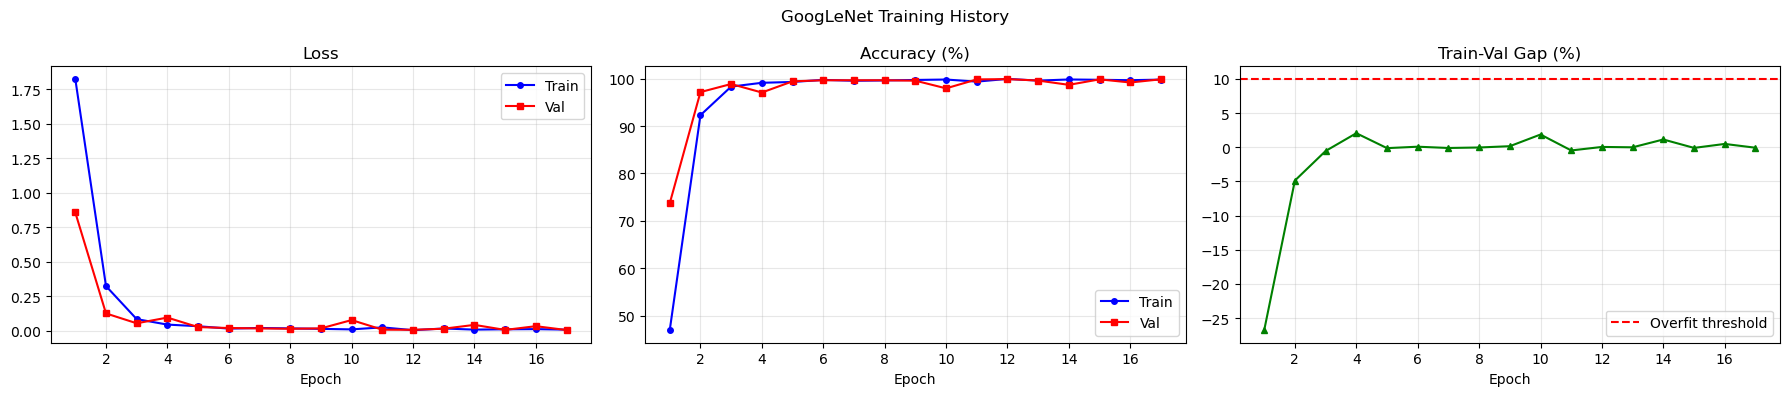

In [26]:
# ══════════════════════════════════════════════════════════════
#  第 8 块：可视化训练曲线
# ══════════════════════════════════════════════════════════════

epochs = [h['epoch'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(epochs, [h['train_loss'] for h in history], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs, [h['val_loss'] for h in history], 'r-s', label='Val', markersize=4)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, [h['train_acc'] for h in history], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs, [h['val_acc'] for h in history], 'r-s', label='Val', markersize=4)
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gap (过拟合程度)
axes[2].plot(epochs, [h['gap'] for h in history], 'g-^', markersize=4)
axes[2].axhline(y=10, color='r', linestyle='--', label='Overfit threshold')
axes[2].set_title('Train-Val Gap (%)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('GoogLeNet Training History')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
#  第 9 块：测试集评估
# ══════════════════════════════════════════════════════════════

if test_loader is not None:
    test_loss, test_acc = evaluate(model, test_loader, criterion, CFG.DEVICE)
    print(f"🧪 测试集 Loss: {test_loss:.4f}")
    print(f"🧪 测试集准确率: {test_acc:.2f}%")
else:
    print("⚠️ 测试集未加载，跳过测试")

In [27]:
# ══════════════════════════════════════════════════════════════
#  第 10 块：单张图片推理
# ══════════════════════════════════════════════════════════════

def predict_image(model, img_path, cfg):
    """预测单张图片，返回 (类别ID, 名称, 置信度)"""
    _, tfm = get_transforms(cfg.IMG_SIZE)
    img = Image.open(img_path).convert('RGB')
    tensor = tfm(img).unsqueeze(0).to(cfg.DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)
        conf, pred = probs.max(1)
    pid = pred.item()
    return pid, SIGN_NAMES.get(pid, "?"), conf.item()


# 用法示例:
# cls_id, name, confidence = predict_image(model, "./GTSRB/Test/00000.png", CFG)
# print(f"预测结果: {name} (类别{cls_id}), 置信度: {confidence:.4f}")

print("✅ 推理函数定义完成")
print("用法: predict_image(model, '图片路径.png', CFG)")

✅ 推理函数定义完成
用法: predict_image(model, '图片路径.png', CFG)


In [28]:
# ══════════════════════════════════════════════════════════════
#  第 11 块：保存/加载模型
# ══════════════════════════════════════════════════════════════

# 保存完整模型（含结构+权重）
torch.save(model, './gtsrb_googlenet_full.pth')
print("✅ 完整模型已保存: gtsrb_googlenet_full.pth")

# 下次加载直接用:
# model = torch.load('./gtsrb_googlenet_full.pth')
# model.to(CFG.DEVICE)
# model.eval()

✅ 完整模型已保存: gtsrb_googlenet_full.pth
